# Advanced Topics

This notebook covers lower-level features for users who need fine-grained control
over the NSQ simulation:

1. **Coordinate system tilts and decenters** — rotating and shifting components
2. **Raw component construction** — building surfaces directly from geometry primitives
3. **RayDatabase analysis** — post-processing phase-space data
4. **Scene validation and diagnostics**
5. **Tips for large simulations** — batch size, memory, and performance

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig, PointSourceConfig,
    IrradianceDetectorConfig, RayDatabaseConfig,
    LensConfig, MirrorConfig,
    SurfaceConfig, InteractionType,
    RefractiveComponent, ReflectiveComponent, AbsorbingComponent,
    LambertianBSDF, SpecularBRDF,
    NSQMaterial, VACUUM,
)
from optiland.nonsequential.components.geometry.analytic.sphere import SphereGeometry
from optiland.nonsequential.components.geometry.analytic.conic import ConicGeometry

spec = Spectrum.monochromatic(0.55)


## 1. Coordinate System Tilts and Decenters

Every component, source, and detector has a `CoordinateSystem` that defines its
position (`x`, `y`, `z` in mm) and orientation (`rx`, `ry`, `rz` in radians).

| Parameter | Effect |
|---|---|
| `x`, `y`, `z` | Translate the element origin |
| `rx` | Rotate around the x-axis (tilt in YZ plane) |
| `ry` | Rotate around the y-axis (tilt in XZ plane) |
| `rz` | Rotate around the z-axis (twist) |

Rotations apply in the order rx → ry → rz (extrinsic Euler angles).

Here we tilt a lens 5° around x and observe the resulting coma:

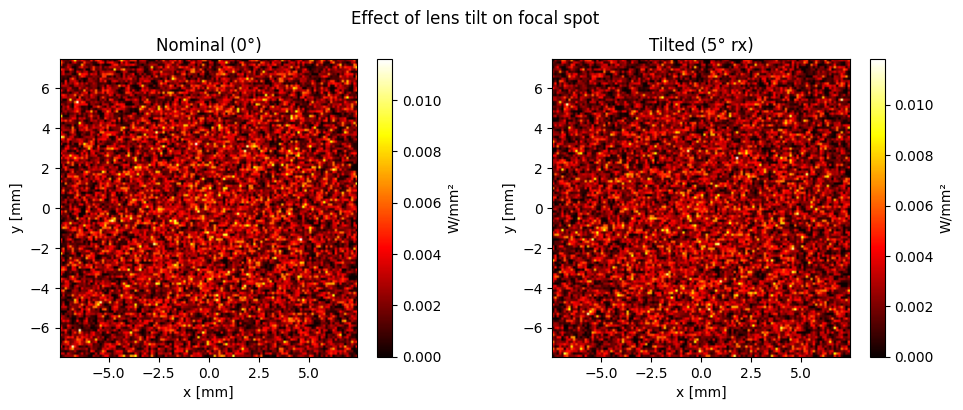

In [2]:
def lens_irr(rx_deg=0.0, n_rays=30_000):
    scene = NSQScene()
    scene.add_source(
        'S', CoordinateSystem(z=-80),
        CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0),
    )
    scene.add_lens(
        'L', CoordinateSystem(z=0, rx=np.radians(rx_deg)),
        LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                   front_aperture_radius=12.5),
    )
    scene.add_detector(
        'D', CoordinateSystem(z=100),
        IrradianceDetectorConfig(width=15, height=15, num_pixels_x=128, num_pixels_y=128),
    )
    r = scene.trace(num_rays=n_rays, seed=42)
    return r.detectors['D']

irr_0deg  = lens_irr(0)
irr_5deg  = lens_irr(5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, irr, title in zip(axes, [irr_0deg, irr_5deg], ['Nominal (0°)', 'Tilted (5° rx)']):
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                            irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm²')
    ax.set_title(title)
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Effect of lens tilt on focal spot', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

## 2. Raw Component Construction

For geometries not covered by `Lens`, `Mirror`, or `Doublet`, you can construct
raw `BaseComponent` objects directly from geometry primitives and register them
via `scene.add_component()`.

Available geometry classes:
- `FinitePlaneGeometry(width, height)` — rectangular flat surface
- `SphereGeometry(radius, aperture_radius)` — spherical surface
- `ConicGeometry(radius, conic, aperture_radius)` — general quadric conic
- `CylindricalFrustumGeometry(r_front, r_back, z_front, z_back)` — barrel surface
- `AnnularPlaneGeometry(inner_radius, outer_radius)` — annular flat surface

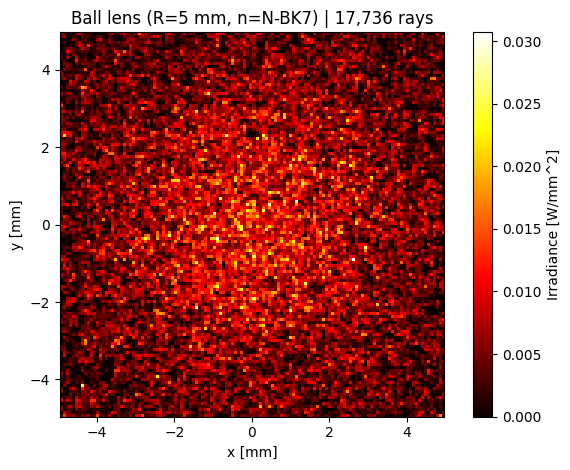

In [3]:
# Build a custom refractive sphere directly
glass = NSQMaterial.from_glass('N-BK7')

# Front surface of a ball lens: convex sphere
front_geom = SphereGeometry(radius=5.0, aperture_radius=4.0)
front_surf = RefractiveComponent(
    cs=CoordinateSystem(z=0),
    geometry=front_geom,
    material_front=VACUUM,
    material_back=glass,
    name='ball_front',
)

# Back surface: concave sphere (same radius, opposite side of ball)
back_geom = SphereGeometry(radius=-5.0, aperture_radius=4.0)
back_surf = RefractiveComponent(
    cs=CoordinateSystem(z=10.0),   # 10 mm diameter ball
    geometry=back_geom,
    material_front=glass,
    material_back=VACUUM,
    name='ball_back',
)

scene_ball = NSQScene()
scene_ball.add_source(
    'S', CoordinateSystem(z=-30),
    CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=3.5),
)
# add_component() registers a raw (single-surface) component directly.
scene_ball.add_component('front', front_surf)
scene_ball.add_component('back',  back_surf)
scene_ball.add_detector(
    'D', CoordinateSystem(z=30),
    IrradianceDetectorConfig(width=10, height=10, num_pixels_x=128, num_pixels_y=128),
)

result_ball = scene_ball.trace(num_rays=30_000, seed=42)
irr_ball = result_ball.detectors['D']

fig = irr_ball.plot(cmap='hot')
plt.title(f'Ball lens (R=5 mm, n=N-BK7) | {irr_ball.num_rays_hit:,} rays')
plt.tight_layout()
plt.show()
plt.close(fig)


## 3. RayDatabase: Phase-Space Analysis

The `RayDatabase` from a `RayDatabaseDetector` gives access to the complete
phase-space of every ray that hit the detector. This supports analyses that the
binned detectors cannot provide, such as:
- Etendue / étendue conservation checks
- Encircled energy fraction
- Spot centroid and shape analysis
- Custom histograms

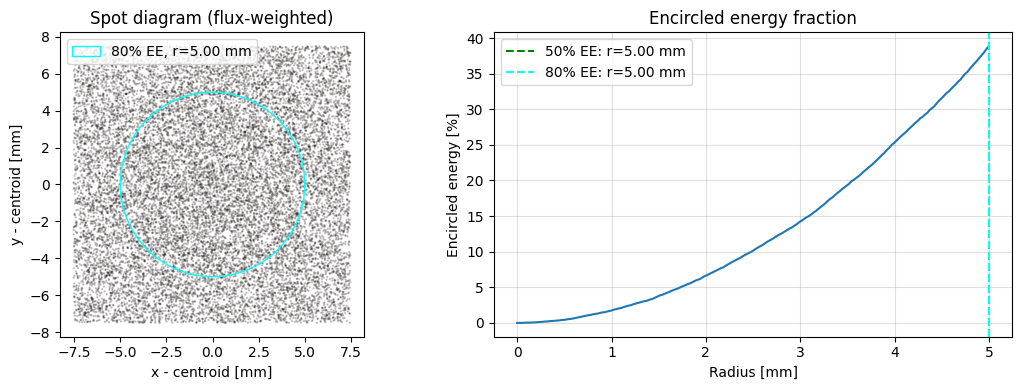

Flux-weighted centroid : (0.031, 0.004) mm
50% encircled-energy radius: 5.000 mm
80% encircled-energy radius: 5.000 mm


In [4]:
scene_rdb = NSQScene()
scene_rdb.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0),
)
scene_rdb.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
scene_rdb.add_detector(
    'RDB', CoordinateSystem(z=100),
    RayDatabaseConfig(width=15, height=15),
)

result_rdb = scene_rdb.trace(num_rays=30_000, seed=42)
db = result_rdb.detectors['RDB']

# --- Encircled energy fraction ---
cx = np.average(db.x, weights=db.flux)  # flux-weighted centroid
cy = np.average(db.y, weights=db.flux)
r_from_centre = np.sqrt((db.x - cx)**2 + (db.y - cy)**2)

radii  = np.linspace(0, 5, 200)
eef    = np.array([db.flux[r_from_centre <= r].sum() / db.flux.sum() for r in radii])
r50    = radii[min(np.searchsorted(eef, 0.50), len(radii) - 1)]
r80    = radii[min(np.searchsorted(eef, 0.80), len(radii) - 1)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(db.x - cx, db.y - cy, s=0.5, alpha=0.2, c=db.flux, cmap='hot')
circle80 = plt.Circle((0, 0), r80, color='cyan', fill=False, lw=1, label=f'80% EE, r={r80:.2f} mm')
axes[0].add_patch(circle80)
axes[0].set_aspect('equal')
axes[0].set_xlabel('x - centroid [mm]'); axes[0].set_ylabel('y - centroid [mm]')
axes[0].set_title('Spot diagram (flux-weighted)')
axes[0].legend()

axes[1].plot(radii, eef * 100)
axes[1].axvline(r50, color='g', linestyle='--', label=f'50% EE: r={r50:.2f} mm')
axes[1].axvline(r80, color='cyan', linestyle='--', label=f'80% EE: r={r80:.2f} mm')
axes[1].set_xlabel('Radius [mm]')
axes[1].set_ylabel('Encircled energy [%]')
axes[1].set_title('Encircled energy fraction')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
plt.close(fig)

print(f"Flux-weighted centroid : ({cx:.3f}, {cy:.3f}) mm")
print(f"50% encircled-energy radius: {r50:.3f} mm")
print(f"80% encircled-energy radius: {r80:.3f} mm")


## 4. Scene Validation

`scene.validate()` checks for the most common configuration mistakes. It is
called automatically by `scene.trace()`, but you can call it explicitly after
building the scene to catch errors early.

In [5]:
# A valid scene
scene_ok = NSQScene()
scene_ok.add_source('S', CoordinateSystem(z=0),
                    PointSourceConfig(spec, total_flux=1.0))
scene_ok.add_detector('D', CoordinateSystem(z=50),
                      IrradianceDetectorConfig(width=30, height=30))
scene_ok.validate()
print("Valid scene: passed")

# A scene missing a detector
scene_bad = NSQScene()
scene_bad.add_source('S', CoordinateSystem(z=0),
                     PointSourceConfig(spec, total_flux=1.0))
try:
    scene_bad.validate()
except ValueError as e:
    print(f"Validation error (expected): {e}")

Valid scene: passed
Validation error (expected): Scene has no detectors. Add at least one detector.


## 5. Performance Tips

### Choosing ray count

Monte Carlo noise scales as $1/\sqrt{N}$, so quadrupling the ray count halves
the noise. Start at 10k-50k rays while you get the geometry right, then raise it
for final results.

### Batch size matters more than you would expect

`batch_size` sets how many rays are traced at once. It does not change the
answer, but it does change the speed: the tracer allocates several temporary
arrays per ray per bounce, and once a batch no longer fits in cache the cost per
ray climbs sharply.

On CPU, batches of roughly 10k-50k rays are usually much faster than the default
of one million. The benchmark below measures it directly, so you can pick a value
for your own machine rather than trusting a rule of thumb.

### Component count

The tracer tests every surface against every live ray, so scenes with many
surfaces cost proportionally more. Drop components that no ray can reach, and use
absorbing surfaces to kill rays that cannot contribute.


In [6]:
import time


def build_bench_scene():
    s = NSQScene()
    s.add_source('S', CoordinateSystem(z=-80),
                 CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=10.0))
    s.add_lens('L', CoordinateSystem(z=0),
               LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                          front_aperture_radius=12.5))
    s.add_detector('D', CoordinateSystem(z=100),
                   IrradianceDetectorConfig(width=20, height=20,
                                            num_pixels_x=64, num_pixels_y=64))
    return s


build_bench_scene().trace(num_rays=5_000, seed=1)   # warm-up

N_BENCH = 400_000
batch_sizes = [10_000, 25_000, 50_000, 100_000, 400_000, 1_000_000]
times, rates, fluxes = [], [], []

for bs in batch_sizes:
    t0 = time.perf_counter()
    r = build_bench_scene().trace(num_rays=N_BENCH, seed=42, batch_size=bs)
    dt = time.perf_counter() - t0
    times.append(dt)
    rates.append(N_BENCH / dt / 1e6)
    fluxes.append(r.detectors['D'].total_flux)
    print(f"batch_size={bs:>9,}: {dt:6.3f} s  ->  {rates[-1]:.3f} M rays/s  "
          f"(flux {fluxes[-1]:.4f} W)")

best = int(np.argmax(rates))
print(f"\nFastest: batch_size={batch_sizes[best]:,} at {rates[best]:.3f} M rays/s, "
      f"{rates[best] / rates[-1]:.1f}x the default")
print(f"Flux spread across all batch sizes: "
      f"{max(fluxes) - min(fluxes):.2e} W (Monte Carlo noise only)")


batch_size=   10,000:  1.202 s  ->  0.333 M rays/s  (flux 0.8642 W)


batch_size=   25,000:  1.191 s  ->  0.336 M rays/s  (flux 0.8643 W)


batch_size=   50,000:  1.741 s  ->  0.230 M rays/s  (flux 0.8639 W)


batch_size=  100,000:  2.003 s  ->  0.200 M rays/s  (flux 0.8651 W)


batch_size=  400,000:  4.031 s  ->  0.099 M rays/s  (flux 0.8648 W)


batch_size=1,000,000:  3.984 s  ->  0.100 M rays/s  (flux 0.8648 W)

Fastest: batch_size=25,000 at 0.336 M rays/s, 3.3x the default
Flux spread across all batch sizes: 1.18e-03 W (Monte Carlo noise only)


## 6. Inspecting Compound Component Internals

`scene.surfaces` is the flat list of every sub-surface the tracer actually sees.
Compound components name their parts, so a lens contributes `L1.front`,
`L1.back` and `L1.edge`, which makes it easy to find the surface you want to
modify or attach a BSDF to.


In [7]:
scene_inspect = NSQScene()
scene_inspect.add_source('S', CoordinateSystem(z=-80),
                         CollimatedSourceConfig(spec, total_flux=1.0,
                                                aperture_radius=10.0))
scene_inspect.add_lens('L1', CoordinateSystem(z=0),
                       LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                                  front_aperture_radius=12.5))
scene_inspect.add_lens('L2', CoordinateSystem(z=40),
                       LensConfig(r1=-80, r2=80, thickness=4, material='N-SF5',
                                  front_aperture_radius=12.5))
scene_inspect.add_detector('D', CoordinateSystem(z=120),
                           IrradianceDetectorConfig(width=10, height=10))

print("Compound components:")
for comp in scene_inspect.component_registry.compounds:
    print(f"  {comp.name}: {len(comp.surfaces)} surfaces")
    for surf in comp.surfaces:
        print(f"    - {surf.name:12s} {type(surf).__name__}")

print(f"\nFlat surface list  : {[s.name for s in scene_inspect.surfaces]}")
print(f"Total sources      : {len(scene_inspect.sources)}")
print(f"Total detectors    : {len(scene_inspect.detectors)}")

# Named surfaces make targeted modification straightforward.
front_of_L2 = next(s for s in scene_inspect.surfaces if s.name == 'L2.front')
print(f"\nLooked up '{front_of_L2.name}': {type(front_of_L2).__name__} "
      f"with aperture radius {front_of_L2.geometry.aperture_radius:.1f} mm")


Compound components:
  L1: 3 surfaces
    - L1.front     RefractiveComponent
    - L1.back      RefractiveComponent
    - L1.edge      AbsorbingComponent
  L2: 3 surfaces
    - L2.front     RefractiveComponent
    - L2.back      RefractiveComponent
    - L2.edge      AbsorbingComponent

Flat surface list  : ['L1.front', 'L1.back', 'L1.edge', 'L2.front', 'L2.back', 'L2.edge']
Total sources      : 1
Total detectors    : 1

Looked up 'L2.front': RefractiveComponent with aperture radius 12.5 mm


## 7. Putting It Together

The benchmark above and the scene it traced, side by side: throughput
against batch size, and the irradiance map the run produced.


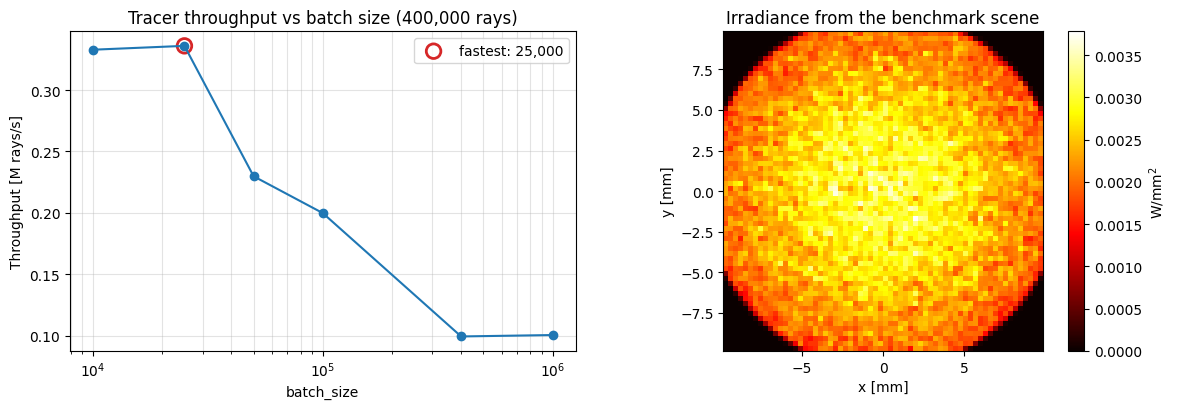

In [8]:
result_bench = build_bench_scene().trace(
    num_rays=200_000, seed=42, batch_size=batch_sizes[best])
irr_bench = result_bench.detectors['D']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.semilogx(batch_sizes, rates, 'o-')
ax.scatter([batch_sizes[best]], [rates[best]], s=110, facecolors='none',
           edgecolors='tab:red', linewidths=2,
           label=f'fastest: {batch_sizes[best]:,}')
ax.set_xlabel('batch_size')
ax.set_ylabel('Throughput [M rays/s]')
ax.set_title(f'Tracer throughput vs batch size ({N_BENCH:,} rays)')
ax.legend()
ax.grid(True, alpha=0.35, which='both')

ax = axes[1]
im = ax.imshow(irr_bench.irradiance, origin='lower', cmap='hot',
               extent=[irr_bench.x_coords[0], irr_bench.x_coords[-1],
                       irr_bench.y_coords[0], irr_bench.y_coords[-1]])
plt.colorbar(im, ax=ax, label='W/mm$^2$')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('Irradiance from the benchmark scene')

plt.tight_layout()
plt.show()


## Summary

- `CoordinateSystem(x, y, z, rx, ry, rz)` - position [mm] and orientation [radians]
- Raw components: `RefractiveComponent`, `ReflectiveComponent`, `AbsorbingComponent`
  plus a geometry, registered with `scene.add_component(name, component)`
- `RayDatabase` supports encircled energy, centroid, spot diagrams and custom analysis
- `scene.validate()` catches missing sources or detectors early
- Compound sub-surfaces are named (`L1.front`, `L1.back`, `L1.edge`), so they can be
  looked up in `scene.surfaces` and modified individually
- Noise falls as $1/\sqrt{N}$; quadruple the rays to halve it
- `batch_size` does not change the answer but strongly affects speed: measure it,
  and expect 10k-50k to beat the default on CPU
- Check `flux_conservation_error` before interpreting any result
